**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")

W = 250          # rolling window size
BLOCK_N = 16     # block size

**Cell 2 — Load and combine returns**

In [2]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

dates = returns.index.to_numpy()
x = returns.sum(axis=1).values * 100   # portfolio P&L, percentage scale
L = -x                                  # loss series: positive = loss
Obs = len(x)
print(f"Total observations (T): {Obs}")

Total observations (T): 7522


**Cell 3 — Block Maxima VaR fitting function**

In [3]:
def block_max_var(L_window, block_n, alpha):
    N = len(L_window)
    n_blocks = int(np.floor(N / block_n))
    if n_blocks < 5:
        raise ValueError(f"Too few blocks: n_blocks={n_blocks}")

    Z = np.array([L_window[j * block_n:(j + 1) * block_n].max() for j in range(n_blocks - 1)])
    Z = np.append(Z, L_window[(n_blocks - 1) * block_n:].max())

    c, mu, sigma = genextreme.fit(Z, loc=np.mean(Z), scale=np.std(Z))

    if np.isnan(c) or np.isnan(mu) or np.isnan(sigma) or sigma <= 0 or np.abs(c) > 10:
        raise ValueError("Degenerate GEV fit")

    var_loss = genextreme.ppf(alpha ** block_n, c, loc=mu, scale=sigma)
    gamma = -c  # scipy genextreme: c = -gamma
    return {"var_loss": var_loss, "gamma": gamma, "sigma": sigma, "mu": mu}

**Cell 4 — Rolling estimation and backtest**

In [4]:
def run_rolling_backtest(x, L, dates, alpha, w=W, block_n=BLOCK_N):
    Obs = len(x)
    n_roll = Obs - w
    results = {key: np.full(n_roll, np.nan) for key in ["var_loss", "gamma", "sigma", "mu"]}

    fail_count = 0
    for i in range(n_roll):
        L_window = L[i:i + w]
        try:
            out = block_max_var(L_window, block_n, alpha)
            for key in results:
                results[key][i] = out[key]
        except Exception:
            fail_count += 1

    print(f"[alpha={alpha}] Failed windows: {fail_count} / {n_roll}")
    print(f"[alpha={alpha}] NaN in VaR: {np.isnan(results['var_loss']).sum()}")

    VaR_series = -results["var_loss"]
    dates_plot = dates[w:w + n_roll]
    L_plot = x[w:w + n_roll]

    assert len(dates_plot) == n_roll == len(L_plot) == len(VaR_series)

    exceed = L_plot < VaR_series
    alpha_hat = exceed.sum() / n_roll

    print(f"[alpha={alpha}] Exceedance ratio alpha_hat: {alpha_hat:.4f}")
    print(f"[alpha={alpha}] Expected (1 - alpha):       {1 - alpha:.4f}")
    print(f"[alpha={alpha}] Number of exceedances:      {exceed.sum()}")

    return dates_plot, L_plot, VaR_series, exceed, results

**Cell 5 — Plotting function (VaR backtest + GEV parameters)**

In [ ]:
def plot_backtest(dates_plot, L_plot, VaR_series, exceed, results, alpha, suffix):
    idx_exceed = np.where(exceed)[0]
    dates_exceed = dates_plot[idx_exceed]
    L_exceed = L_plot[idx_exceed]
    yplus = np.full(len(idx_exceed), np.nanmin(L_plot) - 0.2)

    conf_pct = f"{alpha * 100:.0f}%"

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(dates_plot, L_plot, color="blue", marker="D", s=0.5, alpha=0.6, label="Profit/Loss", zorder=2)
    ax.plot(dates_plot, VaR_series, color="red", linewidth=1, label=f"VaR ({conf_pct})", zorder=3)
    ax.scatter(dates_exceed, L_exceed, color="magenta", marker="D", s=3,
               label=f"Exceedances ({exceed.sum()})", zorder=4)
    ax.scatter(dates_exceed, yplus, color="darkgreen", marker="+", s=70, linewidths=0.5, zorder=4)
    ax.axhline(0, color="black", linewidth=0.3, linestyle="--", alpha=0.4)
    ax.set_title("Block Maxima Model", fontsize=13)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"block_maxima_var_{suffix}.png"),
                dpi=200, transparent=True, bbox_inches="tight")
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(7, 7))
    ax2.plot(dates_plot, results["gamma"], color="blue", linewidth=0.5, label="Shape parameter (gamma)")
    ax2.plot(dates_plot, results["sigma"], color="magenta", linewidth=0.5, label="Scale parameter (sigma)")
    ax2.plot(dates_plot, results["mu"], color="red", linewidth=0.5, label="Location parameter (mu)")
    ax2.set_title("Parameters in Block Maxima Model", fontsize=13)
    ax2.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"block_maxima_gev_parameters_{suffix}.png"),
                dpi=200, transparent=True, bbox_inches="tight")
    plt.show()

**Cell 6 — Run for alpha = 0.99 (1% VaR)**

[alpha=0.99] Failed windows: 0 / 7272
[alpha=0.99] NaN in VaR: 0
[alpha=0.99] Exceedance ratio alpha_hat: 0.0157
[alpha=0.99] Expected (1 - alpha):       0.0100
[alpha=0.99] Number of exceedances:      114


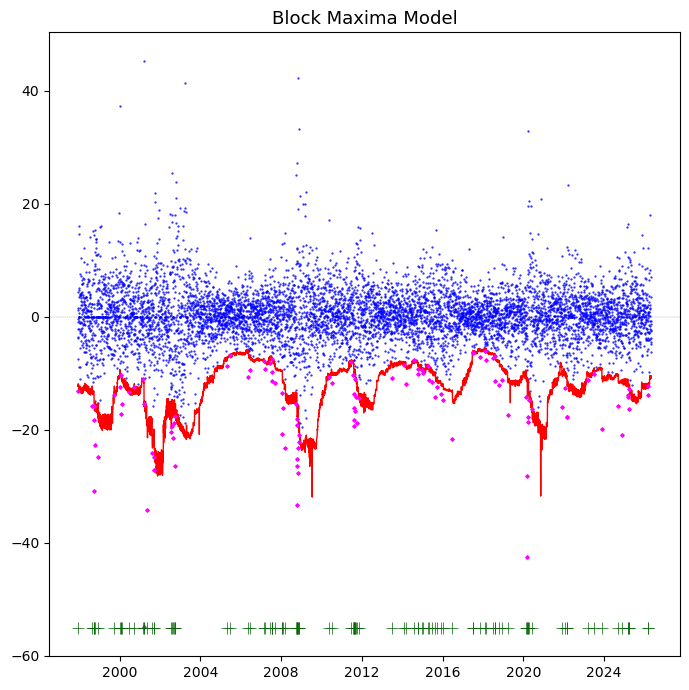

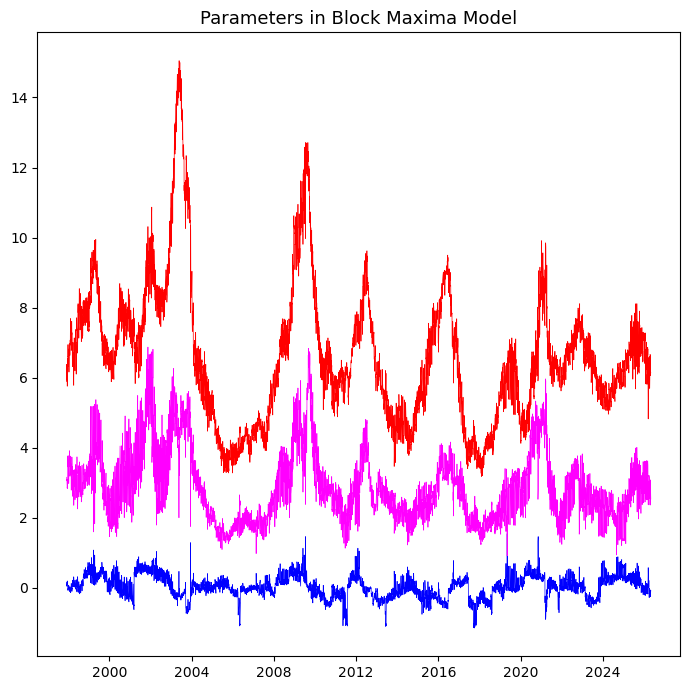

In [9]:
dates_99, L_99, VaR_99, exceed_99, results_99 = run_rolling_backtest(x, L, dates, alpha=0.99)
plot_backtest(dates_99, L_99, VaR_99, exceed_99, results_99, alpha=0.99, suffix="99")

**Cell 7 — Run for alpha = 0.95 (5% VaR)**

[alpha=0.95] Failed windows: 0 / 7272
[alpha=0.95] NaN in VaR: 0
[alpha=0.95] Exceedance ratio alpha_hat: 0.0659
[alpha=0.95] Expected (1 - alpha):       0.0500
[alpha=0.95] Number of exceedances:      479


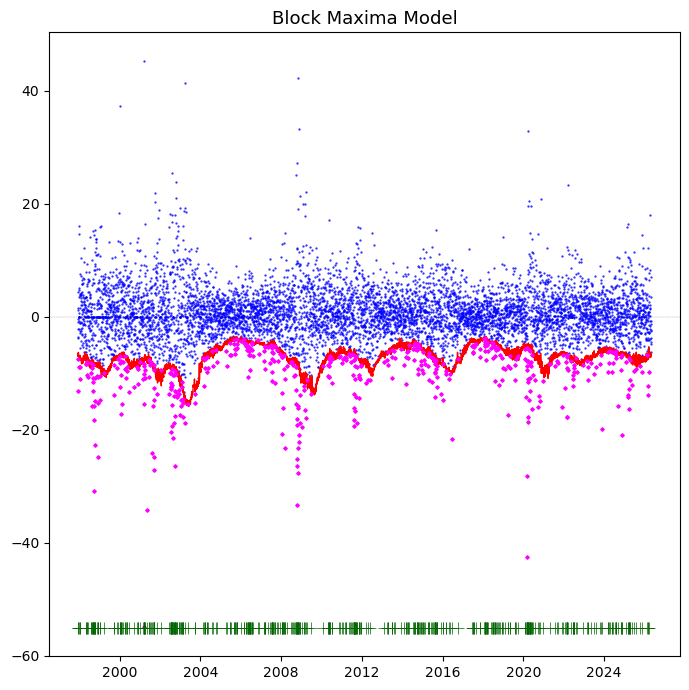

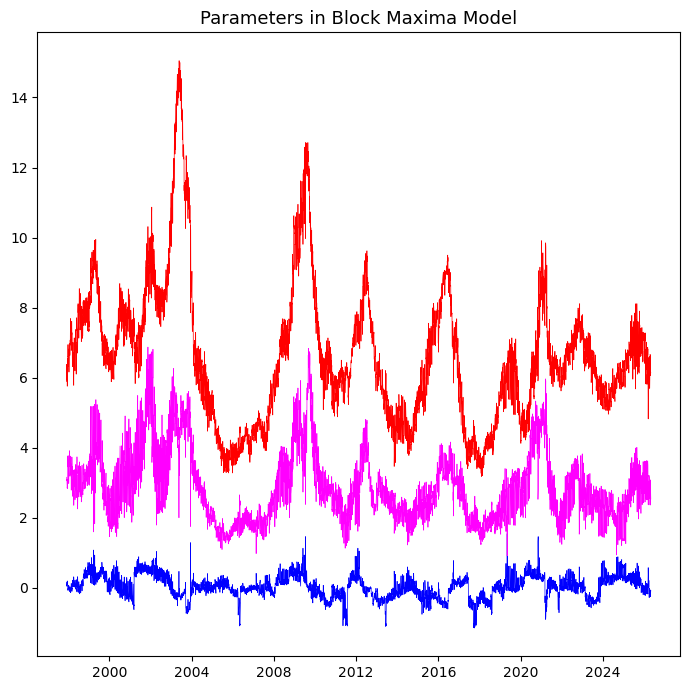

In [10]:
dates_95, L_95, VaR_95, exceed_95, results_95 = run_rolling_backtest(x, L, dates, alpha=0.95)
plot_backtest(dates_95, L_95, VaR_95, exceed_95, results_95, alpha=0.95, suffix="95")

**Cell 8 — Save outputs**

In [11]:
pd.DataFrame({
    "Date": dates_99, "VaR": VaR_99, "PnL": L_99,
    "Exceedance": exceed_99.astype(int),
    "shape_gamma": results_99["gamma"],
    "scale_sigma": results_99["sigma"],
    "loc_mu": results_99["mu"],
}).to_csv(os.path.join(OUTPUT_DIR, "gev_block_maxima_results_99.csv"), index=False)